In [16]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import random
import numpy as np
import os
import pandas as pd
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from torch.cuda.amp import GradScaler, autocast  # Para Mixed Precision Training
from tqdm import tqdm # Import tqdm for progress bar
import copy

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
def set_seed(seed):
    """
    Sets random seeds for reproducibility across different libraries and environments.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # Ensures consistent hash-based operations (e.g., dictionary order)

    torch.manual_seed(seed) # Set CPU seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)       # Set current GPU seed
        torch.cuda.manual_seed_all(seed)   # Set all GPUs seed if multiple are used

        # Ensure deterministic behavior for cuDNN backend (for convolutional operations)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False # Disable cuDNN autotuner to ensure determinism

        # For full PyTorch 1.8+ determinism (may impact performance and cause errors for some ops)
        # The CUBLAS_WORKSPACE_CONFIG variable is needed for certain CUDA ops to be deterministic.
        # It must be set *before* any CUDA context is created (usually done by the time this function runs).
        try:
            os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # Recommended for determinism with CuBLAS >= 10.2
            torch.use_deterministic_algorithms(True)
        except RuntimeError as e:
            # This can happen on older PyTorch versions or if deterministic algorithms cannot be used
            # for a specific operation.
            print(f"Warning: Could not set deterministic algorithms. Error: {e}")
            print("Some PyTorch operations might still be non-deterministic. Consider reviewing PyTorch version and operation types.")
            # If determinism is critical, you might want to stop execution or investigate further.

set_seed(42)

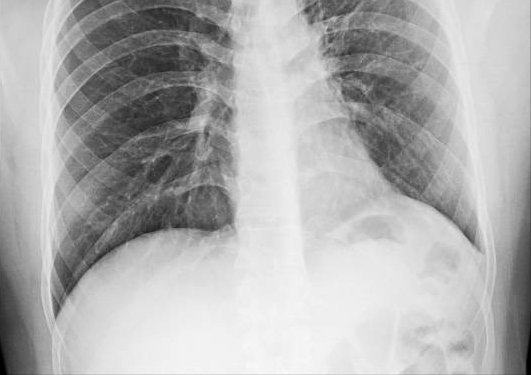

In [19]:
caminho_imagem = "D:/iniciacao_cientifica/untreated_images/images/Entry_ROI/img525.png"
imagem = Image.open(caminho_imagem)
display(imagem)

In [20]:
# Define the specific directory where all the relevant images are located
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\untreated_images\data\Data_Entry_Undergrad_PNG.csv"

# Reading the CSV file
all_xray_df = pd.read_csv(csv_path)

# Create a dictionary to map image filenames (from CSV) to their full file paths.
# We assume the 'Image Label' column in the CSV contains just the filename (e.g., 'img525.png').
all_image_paths_map = {}
# Use glob to find all PNGs *directly within* the specified Entry_ROI directory
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # The key for the dictionary should be just the filename, to match the 'Image Label' column
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

# Printing the number of actual image files found and total rows in the DataFrame
print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV:', all_xray_df.shape[0])

# Mapping the full image paths to the 'Image Label' column in the DataFrame.
# We are using .get() to safely handle cases where an image label from the CSV might not be found.
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# --- Crucial check for unmapped paths ---
# It's important to verify if all entries in your CSV found a corresponding image file.
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"Warning: {unmapped_images_count} images in the CSV could not be mapped to a file path "
          f"from '{image_entry_roi_dir}'. These rows will have 'path' as NaN.")
    # Option: Display a few unmapped entries to debug
    # print("\nSample unmapped CSV entries:")
    # display(all_xray_df[all_xray_df['path'].isnull()].head())
    
    # Option: Remove unmapped rows if they are not needed for further analysis
    # all_xray_df.dropna(subset=['path'], inplace=True)
    # print(f"Removed {unmapped_images_count} unmapped entries. Remaining rows: {len(all_xray_df)}")
else:
    print("All CSV entries successfully mapped to image file paths.")

# Displaying a sample of 3 rows from the DataFrame, now including the new 'path' column
display(all_xray_df.sample(3))

Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV: 1072


,Image Label,Finding Labels,Other,path
992,img993.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...
746,img747.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...
1066,img1067.png,TB,NaN,D:\iniciacao_cientifica\untreated_images\image...


Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV: 1072
Removed 2 unmapped entries. Remaining rows: 1070

Sample of DataFrame with 'path' and 'is_tb' columns:


,Image Label,Finding Labels,path,is_tb
330,img331.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
233,img234.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
478,img479.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
519,img520.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
846,img849.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\226715237.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values[:len(tb_categories)], ax=ax1, palette="viridis") # Slicing for safety


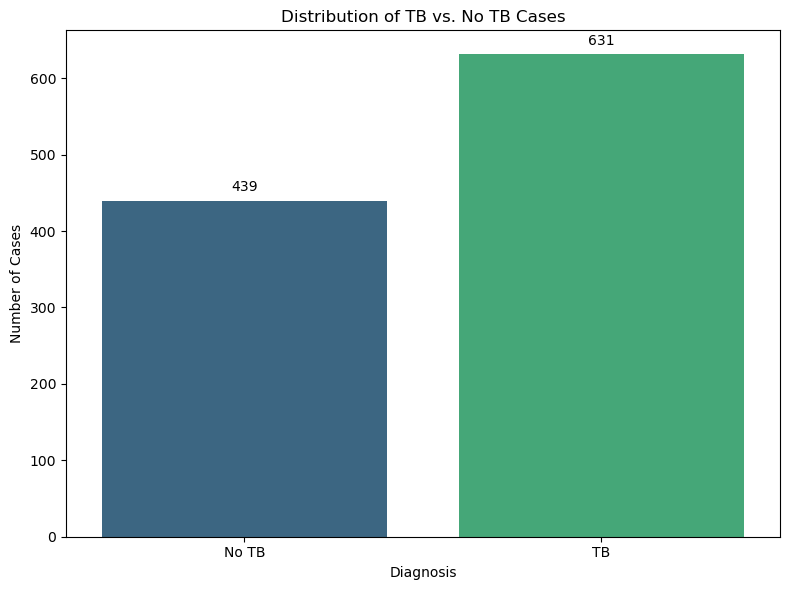

In [21]:
# Assuming previous imports are still active:
# import os, pandas as pd, glob, matplotlib.pyplot as plt, seaborn as sns, IPython.display as display

# Define the specific directory where all the relevant images are located
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\untreated_images\data\Data_Entry_Undergrad_PNG.csv"

# Reading the CSV file
all_xray_df = pd.read_csv(csv_path)

# --- CORRECTED IMAGE PATH MAPPING (Re-applied from previous turn) ---
# Create a dictionary to map image filenames (from CSV) to their full file paths.
# We assume the 'Image Label' column in the CSV contains just the filename (e.g., 'img525.png').
all_image_paths_map = {}
# Use glob to find all PNGs *directly within* the specified Entry_ROI directory
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # The key for the dictionary should be just the filename, to match the 'Image Label' column
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

# Display number of image files found and CSV entries for verification
print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV:', all_xray_df.shape[0])

# Mapping the full image paths to the 'Image Label' column in the DataFrame.
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Crucial check: Drop rows where no image path could be found, as these are unusable.
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"Warning: {unmapped_images_count} images in the CSV could not be mapped to a file path "
          f"from '{image_entry_roi_dir}'. These rows will be dropped.")
    all_xray_df.dropna(subset=['path'], inplace=True)
    print(f"Removed {unmapped_images_count} unmapped entries. Remaining rows: {len(all_xray_df)}")
else:
    print("All CSV entries successfully mapped to image file paths.")

all_xray_df.reset_index(drop=True, inplace=True)
# --- END CORRECTED IMAGE PATH MAPPING ---


# --- SIMPLIFIED 'is_tb' LABEL CREATION ---
# Given the clarification: The only finding labels are "No Findings" and "TB".
# Therefore, we can directly map 'TB' to 1 and 'No Findings' to 0.
# This makes the conversion explicit and robust for these two exact strings.

mapping_dict = {'TB': 1, 'No Findings': 0}
all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)

# It's good practice to ensure no NaNs in 'is_tb' if these are the *only* values
if all_xray_df['is_tb'].isnull().any():
    print(f"Critical Warning: Unexpected 'Finding Labels' found that are neither 'TB' nor 'No Findings'.")
    print("Unique unexpected labels:", all_xray_df[all_xray_df['is_tb'].isnull()]['Finding Labels'].unique())
    # Depending on the severity, you might want to stop execution or drop these rows.
    # For now, we'll continue but be aware.


# Display a sample of the DataFrame to show the new 'path' and 'is_tb' columns
print("\nSample of DataFrame with 'path' and 'is_tb' columns:")
display(all_xray_df[['Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

# --- PLOTTING THE DISTRIBUTION OF THE NEW 'is_tb' LABEL (unchanged, still plots the target) ---
# This plot directly shows the primary classification target (TB vs. No TB),
# which is what your model will learn to predict.
tb_label_counts = all_xray_df['is_tb'].value_counts().sort_index()

# Prepare data for plotting, ensuring both 0 and 1 are accounted for
tb_categories = ['No TB', 'TB']
# Use .get(key, default_value) to safely retrieve counts, in case one category has zero entries.
tb_values = [tb_label_counts.get(0, 0), tb_label_counts.get(1, 0)]

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
sns.barplot(x=tb_categories, y=tb_values[:len(tb_categories)], ax=ax1, palette="viridis") # Slicing for safety

ax1.set_title('Distribution of TB vs. No TB Cases')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')

# Add exact counts on top of bars for clarity
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\2796185981.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")


Image files found in D:/.../Entry_ROI: 1072
Total entries in CSV (before path mapping and cleaning): 1072
Removed 2 unmapped entries. Remaining rows: 1070

Original class counts (0: No TB, 1: TB):
is_tb
1    631
0    439
Name: count, dtype: int64

Minority class 'No TB (0)' count: 439
Undersampling majority class 'TB (1)' to match minority count.

Balanced class counts (0: No TB, 1: TB):
is_tb
1    439
0    439
Name: count, dtype: int64


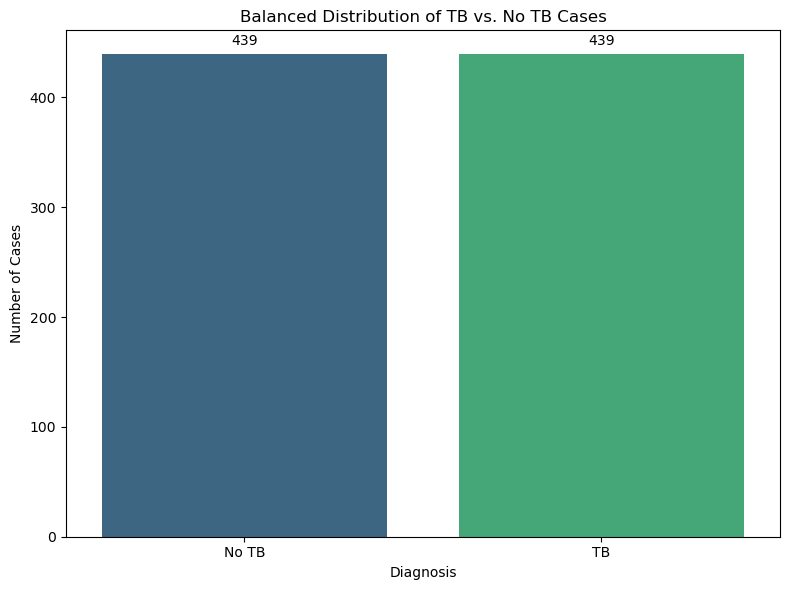


Sample of Balanced DataFrame:


,Image Label,Finding Labels,path,is_tb
528,img90.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
457,img19.png,No Findings,D:\iniciacao_cientifica\untreated_images\image...,0
33,img1005.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
339,img608.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1
300,img809.png,TB,D:\iniciacao_cientifica\untreated_images\image...,1


In [22]:
# --- Correct Image Path Mapping (Applied from our previous discussion) ---
# Define the specific directory where all the relevant images are located
image_entry_roi_dir = r"D:\iniciacao_cientifica\untreated_images\images\Entry_ROI" # Using raw string for Windows paths
csv_path = r"D:\iniciacao_cientifica\untreated_images\data\Data_Entry_Undergrad_PNG.csv"

# Reading the CSV file
all_xray_df = pd.read_csv(csv_path)

# Create a dictionary to map image filenames (from CSV) to their full file paths.
# We assume the 'Image Label' column in the CSV contains just the filename (e.g., 'img525.png').
all_image_paths_map = {}
# Use glob to find all PNGs *directly within* the specified Entry_ROI directory
for full_path in glob(os.path.join(image_entry_roi_dir, '*.png')):
    # The key for the dictionary should be just the filename, to match the 'Image Label' column
    filename = os.path.basename(full_path)
    all_image_paths_map[filename] = full_path

# Display number of image files found and CSV entries for verification
print('Image files found in D:/.../Entry_ROI:', len(all_image_paths_map))
print('Total entries in CSV (before path mapping and cleaning):', all_xray_df.shape[0])

# Mapping the full image paths to the 'Image Label' column in the DataFrame.
all_xray_df['path'] = all_xray_df['Image Label'].map(all_image_paths_map.get)

# Crucial check: Drop rows where no image path could be found, as these are unusable.
unmapped_images_count = all_xray_df['path'].isnull().sum()
if unmapped_images_count > 0:
    print(f"Warning: {unmapped_images_count} images in the CSV could not be mapped to a file path "
          f"from '{image_entry_roi_dir}'. These rows will be dropped.")
    all_xray_df.dropna(subset=['path'], inplace=True)
    print(f"Removed {unmapped_images_count} unmapped entries. Remaining rows: {len(all_xray_df)}")
else:
    print("All CSV entries successfully mapped to image file paths.")

all_xray_df.reset_index(drop=True, inplace=True)
# --- End of Corrected Image Path Mapping ---


# --- Create the 'is_tb' label explicitly (Simplified based on your rule) ---
# The only finding labels are "No Findings" and "TB".
mapping_dict = {'TB': 1, 'No Findings': 0}
all_xray_df['is_tb'] = all_xray_df['Finding Labels'].map(mapping_dict)

# Verify no unexpected labels appeared
if all_xray_df['is_tb'].isnull().any():
    print(f"Critical Warning: Unexpected 'Finding Labels' found that are neither 'TB' nor 'No Findings'.")
    print("Unique unexpected labels:", all_xray_df[all_xray_df['is_tb'].isnull()]['Finding Labels'].unique())
    # Depending on the issue, you might need to handle these rows (e.g., re-assign, drop).

# Display original class counts based on the 'is_tb' column
original_counts = all_xray_df['is_tb'].value_counts()
print("\nOriginal class counts (0: No TB, 1: TB):")
print(original_counts)


# --- Class Balancing: Undersampling the Majority Class ---
# Separate the two classes based on the 'is_tb' column
no_tb_df = all_xray_df[all_xray_df['is_tb'] == 0]
tb_df = all_xray_df[all_xray_df['is_tb'] == 1]

# Determine which class is majority and minority
if len(no_tb_df) > len(tb_df):
    majority_df = no_tb_df
    minority_df = tb_df
    majority_label = 'No TB (0)'
    minority_label = 'TB (1)'
else: # If TB is majority or counts are equal
    majority_df = tb_df
    minority_df = no_tb_df
    majority_label = 'TB (1)'
    minority_label = 'No TB (0)'

# Count of the minority class (this is the target count for both classes after balancing)
minority_count = len(minority_df)
print(f"\nMinority class '{minority_label}' count: {minority_count}")
print(f"Undersampling majority class '{majority_label}' to match minority count.")

# Resample the majority class to match the minority count (undersampling)
majority_resampled_df = majority_df.sample(n=minority_count, random_state=42)

# Combine the resampled majority rows with the minority rows (which are kept entirely)
balanced_df = pd.concat([majority_resampled_df, minority_df]).reset_index(drop=True)

# Verify the new class counts
balanced_counts = balanced_df['is_tb'].value_counts()
print("\nBalanced class counts (0: No TB, 1: TB):")
print(balanced_counts)


# --- Plotting the Balanced Dataset (displayed in notebook) ---
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# Prepare data for plotting, ensuring both 0 and 1 are accounted for
tb_categories = ['No TB', 'TB']
# Use .get(key, default_value) to safely retrieve counts, in case a category has zero entries.
tb_values = [balanced_counts.get(0, 0), balanced_counts.get(1, 0)]

sns.barplot(x=tb_categories, y=tb_values, ax=ax1, palette="viridis")

ax1.set_title('Balanced Distribution of TB vs. No TB Cases')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Diagnosis')

# Add exact counts on top of bars for clarity
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show() # Display the plot in the Jupyter Notebook

# Display a sample of the balanced DataFrame
print("\nSample of Balanced DataFrame:")
display(balanced_df[['Image Label', 'Finding Labels', 'path', 'is_tb']].sample(5))

In [23]:
# Assuming 'balanced_df' is already in memory from the previous successful step.

# Verify the initial balance (re-print for clarity, though it was printed before)
print("Initial class distribution in balanced_df:")
print(balanced_df['is_tb'].value_counts()) # Using .value_counts() directly

# Split the data into train (80%) and temp (20%) sets
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,  # 20% for temp (validation + test)
    stratify=balanced_df['is_tb'],  # Stratify based on 'is_tb' to maintain class balance
    random_state=42 # Ensure reproducibility of the split
)

# Split the temp set into validation (10%) and test (10%) sets
# Since temp is 20% of the data, splitting it 50%/50% ensures 10% for validation and 10% for test.
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # 50% of temp for test (which is 10% of total)
    stratify=temp_df['is_tb'],  # Stratify again to maintain class balance
    random_state=42
)

# Verify the sizes and class distribution for each new set (essential for in-notebook verification)
print("\nTrain set size and class distribution:")
print(f"Size: {len(train_df)}")
print(train_df['is_tb'].value_counts())

print("\nValidation set size and class distribution:")
print(f"Size: {len(val_df)}")
print(val_df['is_tb'].value_counts())

print("\nTest set size and class distribution:")
print(f"Size: {len(test_df)}")
print(test_df['is_tb'].value_counts())

print("\nTrain, validation, and test sets have been successfully created and are in memory.")

# You can optionally display a sample of each DataFrame if you wish (e.g., display(train_df.head()))

Initial class distribution in balanced_df:
is_tb
1    439
0    439
Name: count, dtype: int64

Train set size and class distribution:
Size: 702
is_tb
1    351
0    351
Name: count, dtype: int64

Validation set size and class distribution:
Size: 88
is_tb
0    44
1    44
Name: count, dtype: int64

Test set size and class distribution:
Size: 88
is_tb
1    44
0    44
Name: count, dtype: int64

Train, validation, and test sets have been successfully created and are in memory.


Visualizing class distributions for train, validation, and test sets:


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\4165760009.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\4165760009.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\4165760009.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)


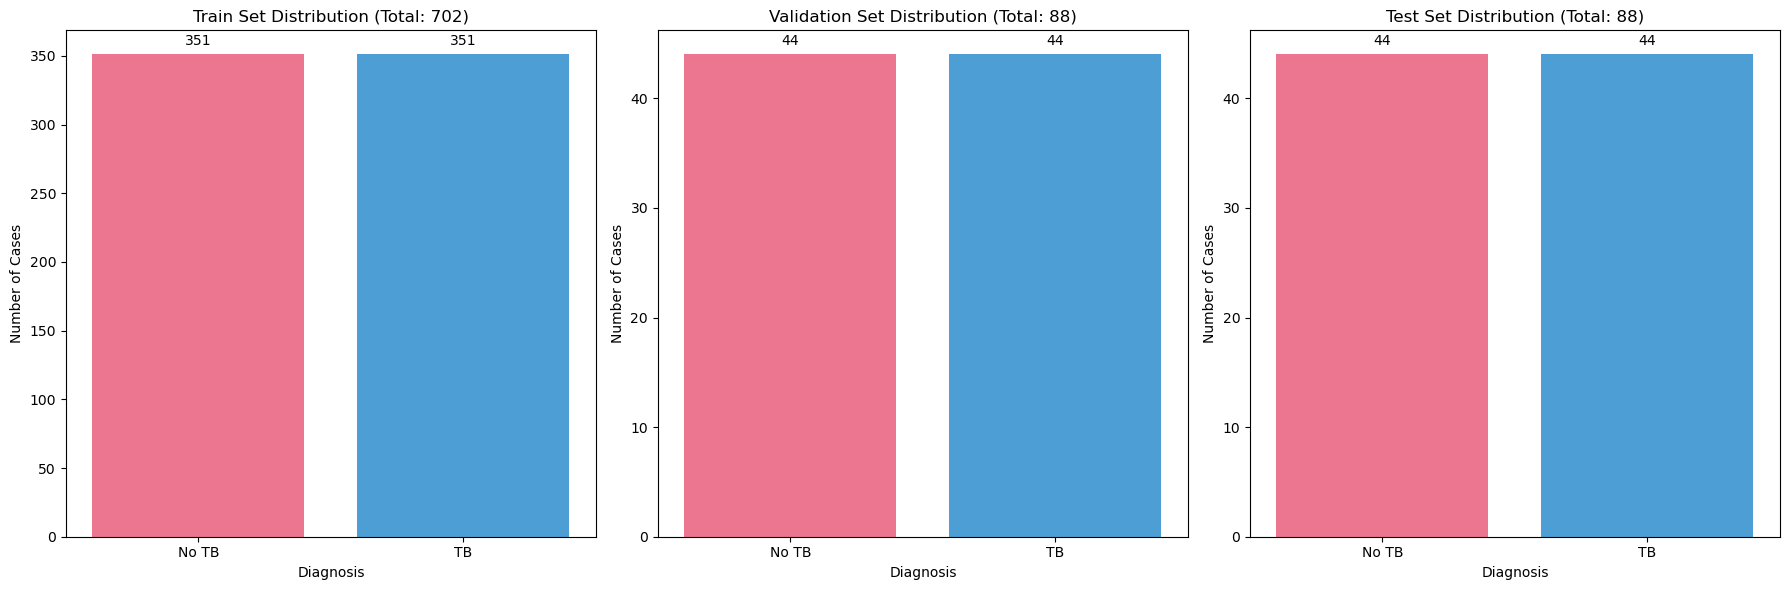

In [24]:
print("Visualizing class distributions for train, validation, and test sets:")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjust figsize as needed for better readability

# Define common properties for categories and colors (optional, but good for consistency)
tb_categories = ['No TB', 'TB']
colors = ['#FF6384', '#36A2EB'] # Or use a seaborn palette like "viridis" or "plasma"


# --- Plot for Train Set ---
train_counts = train_df['is_tb'].value_counts().sort_index()
# Use .get() to safely retrieve counts, in case one category has zero entries (unlikely for balanced sets)
train_values = [train_counts.get(0, 0), train_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=train_values, ax=axes[0], palette=colors)
axes[0].set_title(f'Train Set Distribution (Total: {len(train_df)})')
axes[0].set_ylabel('Number of Cases')
axes[0].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')


# --- Plot for Validation Set ---
val_counts = val_df['is_tb'].value_counts().sort_index()
val_values = [val_counts.get(0, 0), val_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=val_values, ax=axes[1], palette=colors)
axes[1].set_title(f'Validation Set Distribution (Total: {len(val_df)})')
axes[1].set_ylabel('Number of Cases')
axes[1].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')


# --- Plot for Test Set ---
test_counts = test_df['is_tb'].value_counts().sort_index()
test_values = [test_counts.get(0, 0), test_counts.get(1, 0)]
sns.barplot(x=tb_categories, y=test_values, ax=axes[2], palette=colors)
axes[2].set_title(f'Test Set Distribution (Total: {len(test_df)})')
axes[2].set_ylabel('Number of Cases')
axes[2].set_xlabel('Diagnosis')
# Add exact counts on top of bars
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show() # Display the plots directly in the Jupyter Notebook output

In [25]:
# Define the custom dataset class (adapted for your DataFrame)
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): DataFrame with columns 'path' and 'is_tb'.
            transform (callable, optional): Transformations to be applied to the images.
        """
        self.dataframe = dataframe
        self.transform = transform
        # Verify the integrity of image paths right after initialization
        self.dataframe = self._validate_image_paths()

    def _validate_image_paths(self):
        """
        Removes entries with invalid image paths.
        Uses pandas.Series.apply for more efficient checking and boolean indexing for filtering.
        """
        initial_count = len(self.dataframe)
        
        # Create a boolean mask indicating which paths exist
        valid_paths_mask = self.dataframe['path'].apply(os.path.exists)
        
        # Log warnings for missing images
        invalid_paths_df = self.dataframe.loc[~valid_paths_mask]
        if not invalid_paths_df.empty:
            print(f"Warning: {len(invalid_paths_df)} images not found. Examples:")
            for img_path in invalid_paths_df['path'].head(5): # Print only first 5 warnings
                print(f"  - {img_path}")
            
        validated_dataframe = self.dataframe[valid_paths_mask].reset_index(drop=True)
        
        if len(validated_dataframe) == 0:
            raise ValueError("No valid images found in the DataFrame after path validation.")
        
        if len(validated_dataframe) < initial_count:
            print(f"Dataset reduced from {initial_count} to {len(validated_dataframe)} valid images.")
            
        return validated_dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # We assume _validate_image_paths has already filtered out non-existent paths.
        # Any error here likely indicates a corrupted image file or a permission issue.
        img_path = self.dataframe.iloc[idx]['path']
        try:
            image = Image.open(img_path).convert('RGB')
            label = self.dataframe.iloc[idx]['is_tb']
            
            # Convert label directly to torch.Tensor with float32 dtype
            label = torch.tensor(label, dtype=torch.float32)
            
            if self.transform:
                image = self.transform(image)
                
            return image, label
        except Exception as e:
            # CRITICAL: Raise an exception instead of returning None.
            # Returning None will cause issues with DataLoader's collate_fn.
            raise RuntimeError(f"Error loading or processing image {img_path} at index {idx}: {e}") from e

# Function to compute dataset statistics (global mean and std)
def compute_dataset_stats(loader):
    """
    Computes the global pixel-wise mean and standard deviation for normalization
    across all images in the dataset, per channel.
    """
    total_pixels = torch.zeros(3)      # Accumulator for total pixels (H*W*N) per channel
    sum_pixel_values = torch.zeros(3)   # Accumulator for sum of pixel values per channel
    sum_squared_pixel_values = torch.zeros(3) # Accumulator for sum of squared pixel values per channel

    # Wrap the loader with tqdm for a progress bar
    print("Calculating dataset mean and std...")
    for i, (images, _) in enumerate(tqdm(loader, desc="Calculating Stats")):
        # Ensure batch is not empty and contains expected number of dimensions
        if images is None or images.numel() == 0 or images.dim() != 4: # batch, channels, H, W
            print(f"Skipping empty or invalid batch {i}.") # This print would break tqdm bar, so handle carefully
            continue
            
        # Reshape images to (batch_size, channels, H*W)
        images_flat = images.view(images.size(0), images.size(1), -1)

        # Accumulate sums
        sum_pixel_values += images_flat.sum(dim=[0, 2])
        sum_squared_pixel_values += (images_flat ** 2).sum(dim=[0, 2])
        
        # Accumulate total number of pixels added from this batch
        total_pixels += images_flat.size(0) * images_flat.size(2)

    if total_pixels.sum() == 0: # Check if any valid pixel data was processed
        raise ValueError("No valid image data processed to compute statistics.")

    # Calculate global mean: E[X] = sum(X) / N
    mean = sum_pixel_values / total_pixels

    # Calculate global standard deviation: std = sqrt(E[X^2] - (E[X])^2)
    variance = (sum_squared_pixel_values / total_pixels) - (mean ** 2)
    # Ensure variance is non-negative due to potential floating point inaccuracies
    std = torch.sqrt(torch.clamp(variance, min=0.0)) # Clamp to 0.0 to prevent sqrt(negative) issues
    
    return mean, std


# --- Main execution block ---

# train_df should already be in memory from the data splitting step in the notebook.
# If you run this block independently, ensure 'train_df' is defined.
if 'train_df' not in locals():
    print("Error: 'train_df' not found in memory. Please ensure previous data loading and splitting cells were run.")
    raise NameError("'train_df' not found. It should be in memory from previous steps.")

# Define minimal transforms (no normalization yet, as we are calculating it)
temp_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a consistent size
    transforms.ToTensor()          # Convert PIL Image to PyTorch Tensor, scales pixels to [0.0, 1.0]
])

# Create a temporary dataset and DataLoader using the in-memory train_df
try:
    print(f"\nAttempting to compute stats on {len(train_df)} images in train_df.")
    temp_dataset = ChestXRayDataset(dataframe=train_df, transform=temp_transforms)
    
    temp_loader = DataLoader(
        temp_dataset,
        batch_size=32, # Use a reasonable batch size for stats calculation
        shuffle=False, # No need to shuffle for stats calculation
        num_workers=0  # Set to 0 for Windows compatibility; for performance on non-Windows, set > 0
    )
    
    # Compute the mean and std
    computed_mean, computed_std = compute_dataset_stats(temp_loader)
    
    # Print with formatting for clarity
    print("\n--- Computed Dataset Statistics ---")
    print(f"Mean (RGB channel-wise):     {computed_mean.tolist()}")
    print(f"Standard Dev (RGB channel-wise): {computed_std.tolist()}")
    print("---------------------------------")
    
    # Store these values for later use in normalization transforms
    global_dataset_mean = computed_mean
    global_dataset_std = computed_std

except Exception as e:
    print(f"An error occurred during dataset stats computation: {e}")
    # Consider what action to take if stats computation fails (e.g., exit, use default values)


Attempting to compute stats on 702 images in train_df.
Calculating dataset mean and std...


Calculating Stats: 100%|██████████| 22/22 [01:22<00:00,  3.74s/it]


--- Computed Dataset Statistics ---
Mean (RGB channel-wise):     [0.5875234007835388, 0.5875234007835388, 0.5875234007835388]
Standard Dev (RGB channel-wise): [0.2593357264995575, 0.2593357264995575, 0.2593357264995575]
---------------------------------


In [26]:
print(f"Using computed mean for normalization: {global_dataset_mean.tolist()}")
print(f"Using computed std for normalization: {global_dataset_std.tolist()}")

# 1. Training Transforms (with Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.RandomHorizontalFlip(),        # Randomly flip images horizontally
    transforms.RandomRotation(10),            # Randomly rotate images by +/- 10 degrees
    transforms.ColorJitter(                   # Randomly change brightness, contrast, saturation, hue
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.1
    ),
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

# 2. Validation and Test Transforms (no Data Augmentation)
# These should be deterministic to ensure consistent evaluation.
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224 pixels
    transforms.ToTensor(),                    # Convert PIL Image to PyTorch Tensor (scales to [0,1])
    transforms.Normalize(                     # Normalize pixel values
        mean=global_dataset_mean,
        std=global_dataset_std
    )
])

print("\nFinal image transformation pipelines defined:")
print("  - train_transforms (includes data augmentation)")
print("  - val_test_transforms (for validation and test sets)")

Using computed mean for normalization: [0.5875234007835388, 0.5875234007835388, 0.5875234007835388]
Using computed std for normalization: [0.2593357264995575, 0.2593357264995575, 0.2593357264995575]

Final image transformation pipelines defined:
  - train_transforms (includes data augmentation)
  - val_test_transforms (for validation and test sets)


In [27]:
# Assuming ChestXRayDataset class is defined from previous steps
# Assuming train_df, val_df, test_df are in memory from previous steps
# Assuming train_transforms, val_test_transforms are defined from previous steps

# 1. Instantiate Datasets
print("Instantiating datasets...")
train_dataset = ChestXRayDataset(dataframe=train_df, transform=train_transforms)
val_dataset = ChestXRayDataset(dataframe=val_df, transform=val_test_transforms)
test_dataset = ChestXRayDataset(dataframe=test_df, transform=val_test_transforms)

print(f"Train Dataset size: {len(train_dataset)} images")
print(f"Validation Dataset size: {len(val_dataset)} images")
print(f"Test Dataset size: {len(test_dataset)} images")


# 2. Create DataLoaders
# Set batch sizes for training and evaluation
BATCH_SIZE = 32 # Common batch size, adjust based on your GPU memory
NUM_WORKERS = 0 # Set to 0 for Windows compatibility; for performance on non-Windows, set > 0

print("\nCreating DataLoaders...")
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle training data for better generalization
    num_workers=NUM_WORKERS,
    pin_memory=True # Typically good practice for faster GPU transfers if using CUDA
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Do not shuffle validation data for consistent evaluation
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Do not shuffle test data for consistent evaluation
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders created with batch size: {BATCH_SIZE}")
print(f"Number of batches in training: {len(train_loader)}")
print(f"Number of batches in validation: {len(val_loader)}")
print(f"Number of batches in testing: {len(test_loader)}")

# You can optionally peek at one batch to ensure everything is working
try:
    sample_images, sample_labels = next(iter(train_loader))
    print(f"\nSample batch from training DataLoader - Images shape: {sample_images.shape}, Labels shape: {sample_labels.shape}")
except Exception as e:
    print(f"Could not retrieve sample batch: {e}")

Instantiating datasets...
Train Dataset size: 702 images
Validation Dataset size: 88 images
Test Dataset size: 88 images

Creating DataLoaders...
DataLoaders created with batch size: 32
Number of batches in training: 22
Number of batches in validation: 3
Number of batches in testing: 3

Sample batch from training DataLoader - Images shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def define_model(num_classes=1, freeze_pretrained=True):
    """
    Defines and customizes a pre-trained ResNet50 model for binary classification.

    Args:
        num_classes (int): The number of output classes. For binary classification, typically 1.
        freeze_pretrained (bool): If True, freezes the parameters of the pre-trained layers.
                                  Only the new classification head will be trained.
    Returns:
        torch.nn.Module: The configured ResNet50 model.
    """
    print("Loading pre-trained ResNet50 model...")
    # Load a pre-trained ResNet50 model with the best available weights
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    if freeze_pretrained:
        print("Freezing pre-trained layers...")
        for param in model.parameters():
            param.requires_grad = False

    # Get the number of features in the original fully connected (fc) layer
    num_ftrs = model.fc.in_features

    # Replace the original fc layer with a new one for binary classification
    # For binary classification, output is typically 1 (for 1 class vs. another)
    # The BCEWithLogitsLoss (often used later) handles the sigmoid activation.
    model.fc = nn.Linear(num_ftrs, num_classes)
    print(f"Replaced final fully connected layer for {num_classes} output class(es).")

    # Move the model to the appropriate device (GPU if available, else CPU)
    # Ensure 'device' variable is accessible from previous cells or passed in.
    model = model.to(device)
    print(f"Model moved to {device}.")

    return model

# Instantiate your model
model = define_model(num_classes=1, freeze_pretrained=True)

# Print the model architecture to confirm changes
print("\nModel Architecture (last few layers relevant to changes):")
print(model.fc)
print(model.avgpool) # To show where the new fc layer is attached

# Example: Check if layers are frozen (should be False for fc, True for others if frozen)
# for name, param in model.named_parameters():
#     if "fc" not in name: # Check for non-fc layers
#         assert not param.requires_grad, f"Layer {name} is not frozen!"
#     else: # For fc layers
#         assert param.requires_grad, f"Layer {name} is unexpectedly frozen!"
# print("\nParameter freezing check passed (for fc vs other layers).")


Using device: cuda
Loading pre-trained ResNet50 model...
Freezing pre-trained layers...
Replaced final fully connected layer for 1 output class(es).
Model moved to cuda.

Model Architecture (last few layers relevant to changes):
Linear(in_features=2048, out_features=1, bias=True)
AdaptiveAvgPool2d(output_size=(1, 1))


In [29]:
print("Defining Loss Function and Optimizer...")

# 1. Define Loss Function
# For binary classification with logits from the model's output layer (i.e., no sigmoid applied yet)
# BCEWithLogitsLoss is numerically stable and includes sigmoid.
criterion = nn.BCEWithLogitsLoss()
print(f"Loss Function: {criterion.__class__.__name__}")

# 2. Define Optimizer
# Parameters to optimize: Only the new 'fc' layer's parameters have requires_grad=True
# if freeze_pretrained=True was set in define_model.
optimizer = optim.Adam(model.parameters(), lr=0.001) # Learning rate (lr) is a crucial hyperparameter
print(f"Optimizer: {optimizer.__class__.__name__} with Learning Rate: {optimizer.param_groups[0]['lr']}")


# Optionally, you can set up a learning rate scheduler.
# This adjusts the learning rate during training, which can help with convergence.
# A common one is StepLR, which reduces the learning rate by a gamma factor every few epochs.
from torch.optim import lr_scheduler

scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1) # Reduce LR by 10x every 7 epochs
print(f"Learning Rate Scheduler: {scheduler.__class__.__name__}")


print("\nLoss function, optimizer, and scheduler are configured.")

Defining Loss Function and Optimizer...
Loss Function: BCEWithLogitsLoss
Optimizer: Adam with Learning Rate: 0.001
Learning Rate Scheduler: StepLR

Loss function, optimizer, and scheduler are configured.


In [30]:
import time
import copy
from tqdm.notebook import tqdm
import os
import torch # Ensure torch is imported if not already


# Define the number of training epochs (hyperparameter to tune)
NUM_EPOCHS = 20 # You can adjust this number

def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs, device):
    """
    Trains and validates the PyTorch model.

    Args:
        model (torch.nn.Module): The model to train.
        criterion (torch.nn.Module): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer.
        scheduler (torch.optim.lr_scheduler._LRScheduler): The learning rate scheduler.
        train_loader (DataLoader): DataLoader for the training set.
        val_loader (DataLoader): DataLoader for the validation set.
        num_epochs (int): Number of epochs to train for.
        device (torch.device): The device (CPU or CUDA) to use for training.

    Returns:
        tuple: A tuple containing the best performing model (with best weights) and a history dictionary.
    """
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_accuracy = 0.0

    # Initialize GradScaler for mixed precision training (if CUDA is available)
    scaler = None
    if device.type == 'cuda':
        from torch.cuda.amp import GradScaler # Ensure GradScaler is imported
        scaler = GradScaler()
        print("Mixed precision training enabled (using GradScaler).")
    else:
        print("Mixed precision training not enabled (not using CUDA).")


    # History dictionary to store metrics for plotting later
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
    }

    print("\nStarting training...\n")
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            # Iterate over data with a progress bar
            # The 'with' context for autocast/no_grad should properly wrap the forward pass and loss.
            # Optimization and stats accumulation happen PER BATCH.
            for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase E{epoch+1}"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients for THIS BATCH
                optimizer.zero_grad()

                # Forward pass and loss calculation
                # Use autocast only for 'train' phase and CUDA, otherwise always no_grad for evaluation
                with torch.cuda.amp.autocast(enabled=(phase == 'train' and device.type == 'cuda')) if scaler else torch.no_grad():
                    outputs = model(inputs)
                    # For BCEWithLogitsLoss, labels should be (batch_size, 1)
                    if labels.dim() == 1:
                        labels = labels.unsqueeze(1)

                    loss = criterion(outputs, labels)

                # Backward + optimize only if in training phase
                if phase == 'train':
                    if scaler: # Use GradScaler for mixed precision
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()
                    else: # Standard backpropagation for non-CUDA or if scaler not used
                        loss.backward()
                        optimizer.step()

                # Convert logits to probabilities and then to binary predictions for metrics
                # This should happen ONCE per batch AFTER loss calculation (and possibly after optimization)
                preds_proba = torch.sigmoid(outputs)
                binary_preds = (preds_proba > 0.5).float() # Threshold at 0.5

                # Statistics accumulation for THIS BATCH
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(binary_preds == labels.data)

                # Collect all predictions and labels for phase-end metrics calculation
                all_preds.extend(binary_preds.view(-1).cpu().numpy())
                all_labels.extend(labels.view(-1).cpu().numpy())

            # End of batch loop for the current phase

            # Calculate epoch statistics (based on accumulated running_* values)
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            # Store metrics in history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item()) # .item() to convert tensor to Python scalar
                # Step the scheduler AFTER the training phase for the current epoch complete
                # Only step if the scheduler exists and is for the train phase
                if scheduler: # Ensure scheduler is defined
                    scheduler.step()
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            else: # Validation phase
                from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
                val_accuracy = accuracy_score(all_labels, all_preds)
                val_precision = precision_score(all_labels, all_preds, zero_division=0)
                val_recall = recall_score(all_labels, all_preds, zero_division=0)
                val_f1 = f1_score(all_labels, all_preds, zero_division=0)

                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(val_accuracy)
                history['val_precision'].append(val_precision)
                history['val_recall'].append(val_recall)
                history['val_f1'].append(val_f1)

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} (sklearn: {val_accuracy:.4f})')
                print(f'   Precision: {val_precision:.4f} Recall: {val_recall:.4f} F1-Score: {val_f1:.4f}')


                # Deep copy the model if it's the best validation accuracy found so far
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print(f'   -> New best validation accuracy: {best_val_accuracy:.4f}. Model weights saved.')

        print() # Newline after each epoch

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Accuracy: {best_val_accuracy:.4f}')

    # Load best model weights back into the model at the end
    model.load_state_dict(best_model_wts)
    return model, history


# --- Execute Training ---
# Ensure model, criterion, optimizer, scheduler, train_loader, val_loader, device are already defined
# (They should be available from previously run cells)

# Call the training function
final_trained_model, training_history_data = train_model(
    model, criterion, optimizer, scheduler,
    train_loader, val_loader, NUM_EPOCHS, device
)

print("\n--- Training Process Completed ---")
print("The model returned is the one with the best performance on the validation set.")
print("Training history data is stored in 'training_history_data' variable.")


# --- SAVE THE BEST MODEL STATE DICT ---
# Define the directory to save the model
SAVE_MODEL_DIR = r"D:\iniciacao_cientifica\iniciacao-cientifica\saved_models"
MODEL_FILENAME = "best_resnet50_tb_detector.pth"
FULL_SAVE_PATH = os.path.join(SAVE_MODEL_DIR, MODEL_FILENAME)

# Create the directory if it doesn't exist
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)

# Save the state_dict of the final_trained_model (which holds the best_model_wts)
torch.save(final_trained_model.state_dict(), FULL_SAVE_PATH)
print(f"\nBest model state_dict saved to: {FULL_SAVE_PATH}")

Mixed precision training enabled (using GradScaler).

Starting training...

Epoch 1/20
--------------------


C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\96054703.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


train Phase E1:   0%|          | 0/22 [00:00<?, ?it/s]

C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\96054703.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(phase == 'train' and device.type == 'cuda')) if scaler else torch.no_grad():


train Loss: 0.6126 Acc: 0.7308


...

train Phase E20:   0%|          | 0/22 [00:00<?, ?it/s]

C:\Users\Paschoalini\AppData\Local\Temp\ipykernel_1348\96054703.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(phase == 'train' and device.type == 'cuda')) if scaler else torch.no_grad():


train Loss: 0.2546 Acc: 0.9288


val Phase E20:   0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2508 Acc: 0.9205 (sklearn: 0.9205)
   Precision: 0.9302 Recall: 0.9091 F1-Score: 0.9195

Training complete in 36m 26s
Best Validation Accuracy: 0.9318

--- Training Process Completed ---
The model returned is the one with the best performance on the validation set.
Training history data is stored in 'training_history_data' variable.

Best model state_dict saved to: D:\iniciacao_cientifica\iniciacao-cientifica\saved_models\best_resnet50_tb_detector.pth



Starting Test set evaluation...


Test Phase:   0%|          | 0/3 [00:00<?, ?it/s]


--- Test Set Results ---
Loss: 0.2494
Accuracy (Tensor): 0.9318
Accuracy (Sklearn): 0.9318
Precision: 0.9750
Recall: 0.8864
F1-Score: 0.9286
--------------------------


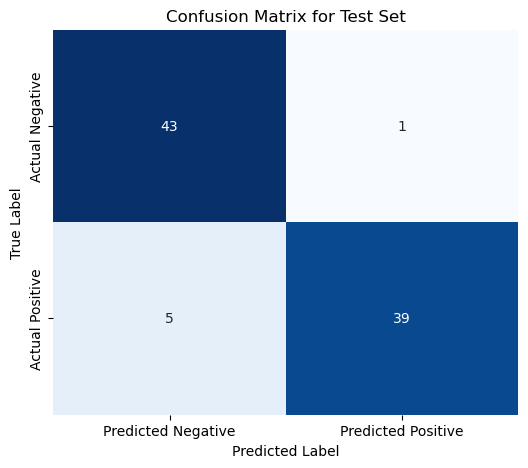


Test set evaluation complete. Results are stored in 'test_results' dictionary.


In [31]:
# Assuming 'final_trained_model' is available from the training cell
# Assuming 'test_loader' is available from the DataLoader creation cell
# Assuming 'criterion' is available from the loss/optimizer definition cell
# Assuming 'device' is available from the device setup cell

def evaluate_model(model, dataloader, criterion, device, phase="Test"):
    """
    Evaluates the model on the given DataLoader and computes various metrics.

    Args:
        model (torch.nn.Module): The trained model to evaluate.
        dataloader (DataLoader): DataLoader for the dataset to evaluate (e.g., test_loader).
        criterion (torch.nn.Module): The loss function.
        device (torch.device): The device (CPU or CUDA) to use for evaluation.
        phase (str): The name of the evaluation phase (e.g., "Test", "Validation").

    Returns:
        dict: A dictionary containing computed loss, accuracy, precision, recall, and F1-score.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []

    print(f"\nStarting {phase} set evaluation...")
    with torch.no_grad():  # Crucial: Disable gradient calculation during inference
        for inputs, labels in tqdm(dataloader, desc=f"{phase} Phase"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # For BCEWithLogitsLoss, labels should be (batch_size, 1)
            if labels.dim() == 1:
                labels = labels.unsqueeze(1)

            loss = criterion(outputs, labels)

            # Convert logits to probabilities and then to binary predictions
            preds_proba = torch.sigmoid(outputs)
            binary_preds = (preds_proba > 0.5).float() # Threshold at 0.5

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(binary_preds == labels.data)

            all_preds.extend(binary_preds.view(-1).cpu().numpy())
            all_labels.extend(labels.view(-1).cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc_tensor = running_corrects.double() / len(dataloader.dataset) # Accuracy from raw tensor sums

    # Compute comprehensive metrics using sklearn
    # Ensure all_labels and all_preds are numpy arrays
    all_labels_np = np.array(all_labels)
    all_preds_np = np.array(all_preds)

    test_accuracy = accuracy_score(all_labels_np, all_preds_np)
    test_precision = precision_score(all_labels_np, all_preds_np, zero_division=0)
    test_recall = recall_score(all_labels_np, all_preds_np, zero_division=0)
    test_f1 = f1_score(all_labels_np, all_preds_np, zero_division=0)
    
    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels_np, all_preds_np)

    print(f"\n--- {phase} Set Results ---")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy (Tensor): {epoch_acc_tensor:.4f}") # Accuracy from raw tensor sum check
    print(f"Accuracy (Sklearn): {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1-Score: {test_f1:.4f}")
    print("--------------------------")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {phase} Set')
    plt.show()

    return {
        'loss': epoch_loss,
        'accuracy_tensor': epoch_acc_tensor.item(),
        'accuracy_sklearn': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': test_f1,
        'confusion_matrix': cm
    }

# --- Execute Test Set Evaluation ---
test_results = evaluate_model(final_trained_model, test_loader, criterion, device, phase="Test")

print("\nTest set evaluation complete. Results are stored in 'test_results' dictionary.")

Displaying 5 random images with predictions:
------------------------------------------------------------


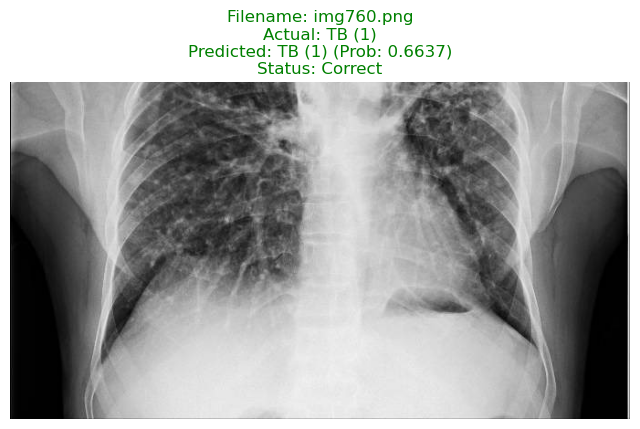

------------------------------------------------------------


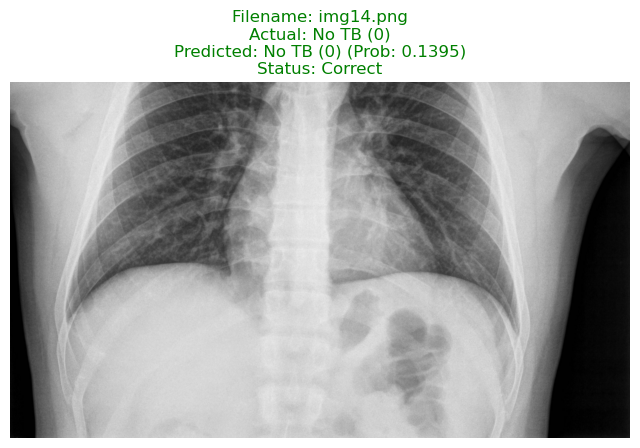

------------------------------------------------------------


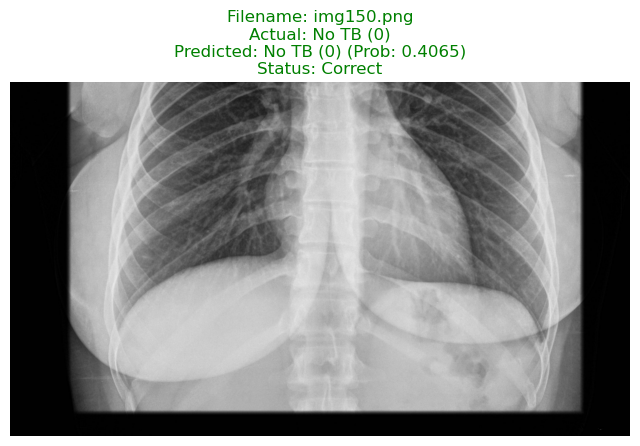

------------------------------------------------------------


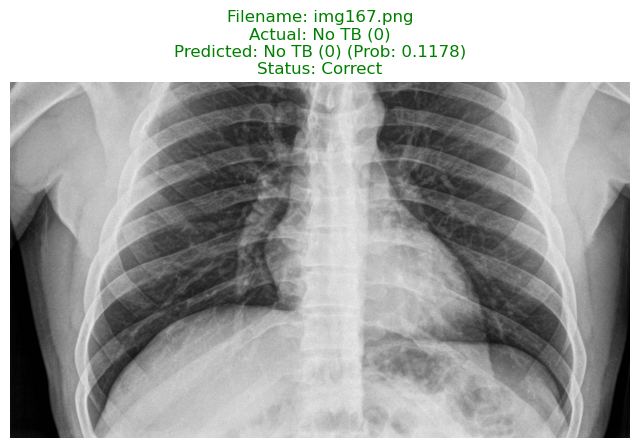

------------------------------------------------------------


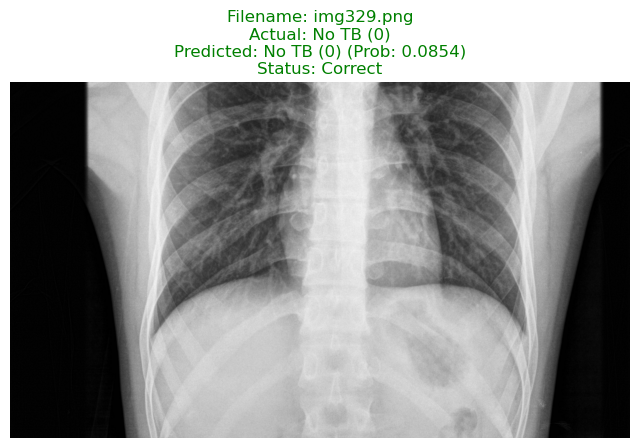

------------------------------------------------------------


In [32]:
# Set the model to evaluation mode
final_trained_model.eval()

# Helper function to convert prediction (logit) to readable label
def get_label_name(label_value):
    return "TB" if label_value == 1 else "No TB"

def display_predictions(num_images=5):
    """
    Loads random images from the test set, makes predictions, and displays them
    alongside the actual label and model's prediction.
    """
    if len(test_df) == 0:
        print("Test DataFrame is empty. Cannot display predictions.")
        return

    print(f"Displaying {min(num_images, len(test_df))} random images with predictions:")
    print("-" * 60)

    # Convert test_df to a list of dictionaries for easier random sampling
    test_samples = test_df.to_dict('records')

    # Select random indices
    if len(test_samples) > num_images:
        selected_samples = random.sample(test_samples, num_images)
    else:
        selected_samples = test_samples # If test set is smaller, show all

    for i, sample in enumerate(selected_samples):
        img_path = sample['path']
        true_label = sample['is_tb']
        filename = os.path.basename(img_path)

        try:
            # Load the original image (for display)
            original_image = Image.open(img_path).convert('RGB')

            # Apply transformations for model input
            # Use original val_test_transforms which includes ToTensor and Normalize
            input_tensor = val_test_transforms(original_image)
            input_batch = input_tensor.unsqueeze(0) # Add a batch dimension

            # Move input to the same device as the model
            input_batch = input_batch.to(device)

            # Make prediction
            with torch.no_grad():
                output_logits = final_trained_model(input_batch)
                prediction_proba = torch.sigmoid(output_logits).item() # Get probability from logit
                predicted_label = 1 if prediction_proba > 0.5 else 0

            # Determine if correct
            is_correct = (predicted_label == true_label)
            status_text = "Correct" if is_correct else "Incorrect"
            status_color = "green" if is_correct else "red"

            # Display the image and information
            plt.figure(figsize=(8, 7)) # Adjust figure size as needed
            plt.imshow(original_image)
            plt.axis('off') # Hide axes

            title_text = (
                f"Filename: {filename}\n"
                f"Actual: {get_label_name(true_label)} ({true_label})\n"
                f"Predicted: {get_label_name(predicted_label)} ({predicted_label}) (Prob: {prediction_proba:.4f})\n"
                f"Status: {status_text}"
            )
            plt.title(title_text, color=status_color)
            plt.show()

            print("-" * 60) # Separator for next image

        except Exception as e:
            print(f"Error processing image {filename} at path {img_path}: {e}")
            print("-" * 60)

# Call the function to display 5 random images
display_predictions(num_images=5)